## 3. Logistic Regression

### 3.1 Packages importeren 

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    f1_score, roc_auc_score, classification_report, accuracy_score
)
import glob
from datetime import datetime
from scipy import stats

from preprocessing import(
    load_dataset,
    preprocess_text,
    my_tokenizer,
)

### 3.2 Dataset inladen 

In [17]:
df = load_dataset()
y = df['Product']
X = df['Omschrijving']

### 3.3 Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

### 3.4 Pipeline + Hyperparameter Tuning

#### 3.4.1 Logistic Regression Pipeline

In [19]:
logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer( # TF-IDF vectorizer met de preprocesser en tokenizer van hierboven 
        preprocessor=preprocess_text,
        tokenizer=my_tokenizer,
        analyzer='word', # werkt op woord niveau (geen characters, geen zinnen)
        ngram_range=(1,2), # unigrams = 'credit', bigrams = 'credit card'. Verbetert de prestaties van het mmodel 
        token_pattern=None # None want danb word onze custom tokenizer gebruikt
    )),
    ('model', LogisticRegression(max_iter=10000, class_weight='balanced'))   # Logistische regressie model met gebalanceerde klassengewichten
])

#### 3.4.2 RandomizedSearchCV

In [20]:
random_params = {
    'model__C': stats.loguniform(0.01, 100), # Regularisatie sterkte
    'model__class_weight': ['balanced', None],
    'tfidf__min_df': [1,2,3,5],
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'tfidf__ngram_range': [(1,1), (1,2)] # unigrams en bigrams
}

random_search = RandomizedSearchCV(
    logreg_pipeline,
    param_distributions=random_params,
    n_iter=20, # aantal combinaties om te proberen
    scoring='f1_weighted', # optimaliseren op gewogen F1-score
    cv=3, # 3-voudige cross-validatie
    verbose=1,
    n_jobs=-1, # gebruik alle beschikbare CPU cores
    random_state=42
)

random_search.fit(X_train, y_train)
best = random_search.best_params_

print("Beste parameters uit random search:", best)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Beste parameters uit random search: {'model__C': np.float64(17.12337597316399), 'model__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}


#### 3.4.3 GridSearchCV

In [21]:
grid_params = {
    'model__C': [best['model__C'] * 0.5, best['model__C'], best['model__C'] * 2],
    'model__class_weight': [best['model__class_weight']],
    'tfidf__min_df': [best['tfidf__min_df'], best['tfidf__min_df'] + 1],
    'tfidf__max_df': [best['tfidf__max_df']],
    'tfidf__ngram_range': [best['tfidf__ngram_range']]
}

grid = GridSearchCV(logreg_pipeline, param_grid=grid_params, scoring = 'f1_weighted', cv=3, n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)
logreg_pipeline = grid.best_estimator_

print("Beste parameters na gridsearch:", grid.best_params_)
print("Beste score na gridsearch:", grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Beste parameters na gridsearch: {'model__C': np.float64(17.12337597316399), 'model__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Beste score na gridsearch: 0.8507406824394791


In [22]:
# Verdere hyperparametertuning met uitgebreidere TF-IDF instellingen
best_grid_params = grid.best_params_
c_center = best_grid_params['model__C']
c_low = max(c_center / 5, 1e-3)
c_high = c_center * 5

min_df_base = int(best_grid_params['tfidf__min_df'])
max_df_base = best_grid_params['tfidf__max_df']
ngram_base = best_grid_params['tfidf__ngram_range']

min_df_candidates = sorted({max(1, min_df_base - 1), min_df_base, min_df_base + 1, min_df_base + 2})
max_df_candidates = sorted({round(max(0.75, max_df_base - 0.05), 2), round(max_df_base, 2), round(min(0.99, max_df_base + 0.05), 2)})

extended_params = {
    'model__C': stats.loguniform(c_low, c_high),
    'model__class_weight': ['balanced', best_grid_params['model__class_weight']],
    'model__solver': ['lbfgs', 'saga'],
    'tfidf__min_df': min_df_candidates,
    'tfidf__max_df': max_df_candidates,
    'tfidf__ngram_range': [ngram_base, (1, 2), (1, 3)],
    'tfidf__max_features': [30000, 50000, None],
    'tfidf__sublinear_tf': [True, False],
    'tfidf__norm': ['l2', None],
    'tfidf__binary': [False, True],
    'tfidf__use_idf': [True, False]
}

extended_search = RandomizedSearchCV(
    logreg_pipeline,
    param_distributions=extended_params,
    n_iter=40,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=92
)

extended_search.fit(X_train, y_train)
logreg_pipeline = extended_search.best_estimator_

print("Beste parameters na uitgebreide random search:", extended_search.best_params_)
print("Beste score na uitgebreide random search:", extended_search.best_score_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits


/Users/lerat/Documents/SCHOOL/DataProject1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lerat/Documents/SCHOOL/DataProject1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Beste parameters na uitgebreide random search: {'model__C': np.float64(35.347699783229835), 'model__class_weight': 'balanced', 'model__solver': 'lbfgs', 'tfidf__binary': False, 'tfidf__max_df': 0.9, 'tfidf__max_features': None, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}
Beste score na uitgebreide random search: 0.853674911688114


#### 3.4.4 Cross-validation (betrouwbaarheid testen)

In [23]:
scores = cross_val_score(logreg_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print("CV F1-score:", scores.mean())
print("CV F1-scores per fold:", scores)

CV F1-score: 0.8569389669123699
CV F1-scores per fold: [0.85700377 0.86837087 0.84118814 0.85527508 0.86285697]


### 3.6 Evaluatie Modelprestaties 

#### 3.6.1 Voorspellingen

In [24]:
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)

#### 3.6.2 Totale metrics

In [25]:
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

print(f'Accuracy Logistic Regression: {accuracy_logreg:.3f}')
print(f"F1 Logistic Regression: {f1_logreg:.3f}")

Accuracy Logistic Regression: 0.855
F1 Logistic Regression: 0.854


#### 3.6.3 Classification report

In [26]:
print(classification_report(y_test, y_pred_logreg))

                    precision    recall  f1-score   support

      Bankrekening       0.87      0.86      0.86       446
Consumentenkrediet       0.74      0.64      0.69       284
        Creditcard       0.82      0.85      0.83       564
         Hypotheek       0.92      0.94      0.93       994
           Incasso       0.85      0.86      0.85      1223
Kredietregistratie       0.84      0.83      0.83       934

          accuracy                           0.85      4445
         macro avg       0.84      0.83      0.83      4445
      weighted avg       0.85      0.85      0.85      4445



#### 3.6.4 Confusion Matrix

[[ 385    2   31   12    9    7]
 [   6  182   15   17   44   20]
 [  21    9  477    5   28   24]
 [  16    6    6  936   13   17]
 [  14   25   26   30 1046   82]
 [   3   22   27   15   94  773]]


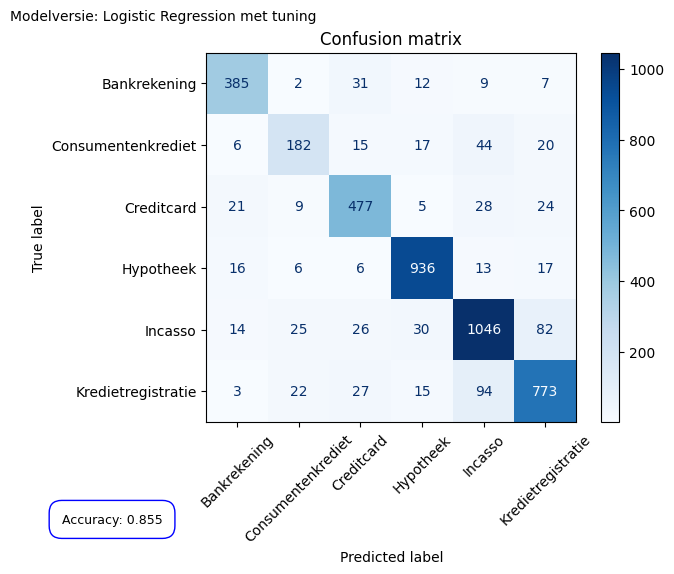

In [27]:
cm = confusion_matrix(y_test, y_pred_logreg)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logreg,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: Logistic Regression met tuning", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {accuracy_logreg:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_logreg_met_tuning.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()

#### 3.6.5 AUC-score (multiclass)

In [28]:
auc_logreg = roc_auc_score(y_test, y_proba_logreg, multi_class='ovr')
print(f"AUC: {auc_logreg:.3f}")

AUC: 0.971


#### 3.6.6 ROC curves per productsector

In [29]:
print("Klassen:", logreg_pipeline['model'].classes_) # dit zijn alle productsectoren in het model 4

Klassen: ['Bankrekening' 'Consumentenkrediet' 'Creditcard' 'Hypotheek' 'Incasso'
 'Kredietregistratie']


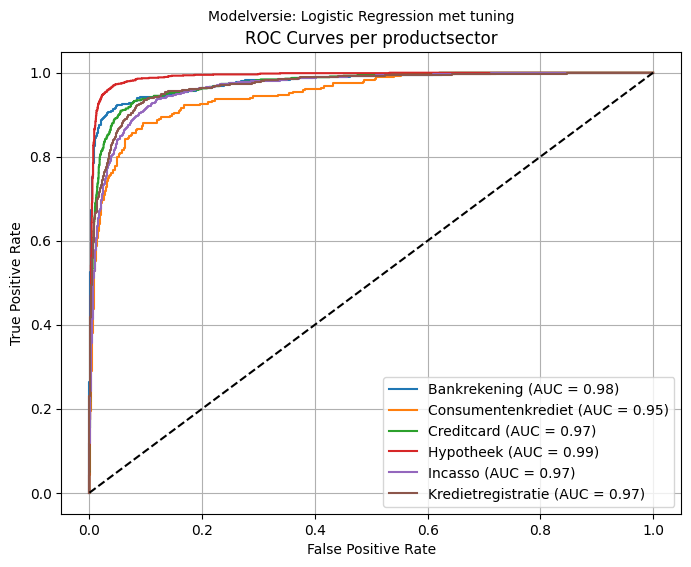

In [30]:
classes = logreg_pipeline['model'].classes_ # krijg de klassen(productsectoren) uit het model
plt.figure(figsize=(8,6))

for i in range(len(classes)): # loop over elke productsector
    class_name = classes[i]
    y_binary = (y_test == class_name).astype(int) # binaire labels voor de huidige produyctsector
    proba = y_proba_logreg[:, i] # waarschijnlijkheden voor de huidige productsector
    fpr, tpr, _ = roc_curve(y_binary, proba) # bereken FPR en TPR 
    auc_score = roc_auc_score(y_binary, proba) # bereken AUC 

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score:.2f})')

plt.plot([0,1], [0,1], '--',color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per productsector')
plt.suptitle("Modelversie: Logistic Regression met tuning", fontsize=10, y=0.95) # ! naam aanpassen per modelversie
plt.legend()
plt.grid(True)
plt.savefig("afbeeldingen/logreg_roc_curves_met_tuning.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()